In [36]:
# ============================================================
# NOTEBOOK 1 - Imports
# ============================================================
from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from scipy.signal import find_peaks

import OrcFxAPI


In [37]:
# ============================================================
# NOTEBOOK 2 - Paden en experimentdefinitie
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")


exp_paths = {
    "spring": {
        "pitch": [
            data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay3.h5m",
        ],
        "roll": [
            data_root / "02" / "002" /  "34224_03CB_02_002_003_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_003_01_Decay2.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_004_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_004_01_Decay2.h5m",
        ],
        "heave": [
            data_root / "02" / "002" /  "34224_03CB_02_002_006_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_006_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_007_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_008_01_Decay1.h5m",
        ],
    },

    "fixedwith": {
        "pitch": [
            data_root / "02" / "003" / "34224_03CB_02_003_001_01_Decay1.h5m",
            data_root / "02" / "003" /"34224_03CB_02_003_002_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_003_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "003" /  "34224_03CB_02_003_004_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_005_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_006_01_Decay1.h5m",
        ],
        "heave": [
            data_root / "02" / "003" /  "34224_03CB_02_003_007_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_008_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_009_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_010_01_Decay1.h5m",
        ],
    },

    "fixedwithout": {
        "pitch": [
            data_root / "02" / "004" / "34224_03CB_02_004_001_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_002_01_Decay1.h5m",
            data_root / "02" / "004" /"34224_03CB_02_004_003_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_004_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "004" /  "34224_03CB_02_004_005_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_006_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_007_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_008_01_Decay1.h5m",
            
        ],
        "heave": [
            data_root / "02" / "004" / "34224_03CB_02_004_009_01_Decay1.h5m",
            data_root / "02" / "004" /  "34224_03CB_02_004_010_01_Decay1.h5m",
            data_root / "02" / "004" /  "34224_03CB_02_004_011_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_012_01_Decay1.h5m",
        ],
    }
}


exp_paths = {
    "spring": {
    
        "roll": [
            data_root / "02" / "002" /  "34224_03CB_02_002_003_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_003_01_Decay2.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_004_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_004_01_Decay2.h5m",
        ],
      
    },

    "fixedwith": {
    
        "roll": [
            data_root / "02" / "003" /  "34224_03CB_02_003_004_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_005_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_006_01_Decay1.h5m",
        ],
      
    },

    "fixedwithout": {
       
        "roll": [
            data_root / "02" / "004" /  "34224_03CB_02_004_005_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_006_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_007_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_008_01_Decay1.h5m",
            
        ],
       
    }
}

# exp_paths = {
#     "spring": {
#         "pitch": [
#             data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay1.h5m",
#             data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay2.h5m",
#             data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay3.h5m",
#         ],
#     },

#     "fixedwith": {
#         "pitch": [
#             data_root / "02" / "003" / "34224_03CB_02_003_001_01_Decay1.h5m",
#             data_root / "02" / "003" /"34224_03CB_02_003_002_01_Decay1.h5m",
#             data_root / "02" / "003" /  "34224_03CB_02_003_003_01_Decay1.h5m",
#         ],
#     },

#     "fixedwithout": {
#         "pitch": [
#             data_root / "02" / "004" / "34224_03CB_02_004_001_01_Decay1.h5m",
#             data_root / "02" / "004" / "34224_03CB_02_004_002_01_Decay1.h5m",
#             data_root / "02" / "004" /"34224_03CB_02_004_003_01_Decay1.h5m",
#             data_root / "02" / "004" / "34224_03CB_02_004_004_01_Decay1.h5m",
#         ],
#     }
# }

# exp_paths = {
#     "spring": {
#         "heave": [
#             data_root / "02" / "002" /  "34224_03CB_02_002_006_01_Decay1.h5m",
#             data_root / "02" / "002" /  "34224_03CB_02_002_006_01_Decay2.h5m",
#             data_root / "02" / "002" / "34224_03CB_02_002_007_01_Decay1.h5m",
#             data_root / "02" / "002" /  "34224_03CB_02_002_008_01_Decay1.h5m",
#         ],
#     },

#     "fixedwith": {
        
#         "heave": [
#             data_root / "02" / "003" /  "34224_03CB_02_003_007_01_Decay1.h5m",
#             data_root / "02" / "003" / "34224_03CB_02_003_008_01_Decay1.h5m",
#             data_root / "02" / "003" / "34224_03CB_02_003_009_01_Decay1.h5m",
#             data_root / "02" / "003" / "34224_03CB_02_003_010_01_Decay1.h5m",
#         ],
#     },

#     "fixedwithout": {
    
#         "heave": [
#             data_root / "02" / "004" / "34224_03CB_02_004_009_01_Decay1.h5m",
#             data_root / "02" / "004" /  "34224_03CB_02_004_010_01_Decay1.h5m",
#             data_root / "02" / "004" /  "34224_03CB_02_004_011_01_Decay1.h5m",
#             data_root / "02" / "004" / "34224_03CB_02_004_012_01_Decay1.h5m",
#         ],
#     }
# }


# exp_paths = {
#     "spring": {
#         "pitch": [
#             data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay1.h5m",
#         ],
#     },

#     "fixedwith": {
#         "roll": [
#             data_root / "02" / "003" / "34224_03CB_02_003_004_01_Decay1.h5m",
#         ],
#     },

#     "fixedwithout": {
#         "heave": [
#             data_root / "02" / "004" / "34224_03CB_02_004_010_01_Decay1.h5m",
#         ],
#     }
# }

# exp_paths = {
#     "spring": {
#         "pitch": [
#             data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay1.h5m",
#         ],
#     },
# }

# OrcaFlex modelbestanden
model_map = {
    "spring": {
        "40s": orca_root / "Harlequin_spring_40s.dat",
        "120s": orca_root / "Harlequin_spring_120s.dat",
    },
    "fixedwith": {
        "40s": orca_root / "Harlequin_fixed_40s.dat",
        "120s": orca_root / "Harlequin_fixed_120s.dat",
    },
    "fixedwithout": {
        "40s": orca_root / "Harlequin_fixed_40s.dat",
        "120s": orca_root / "Harlequin_fixed_120s.dat",
    }
}

# Signalen in h5m
signal_map = {
    "pitch": "UnfilteredSignals/PITCH (unfiltered)",
    "roll": "UnfilteredSignals/ROLL (unfiltered)",
    "heave": "UnfilteredSignals/Z_COG (unfiltered)"
}

time_signal_map = {
    "pitch": "UnfilteredSignals/time",
    "roll": "UnfilteredSignals/time",
    "heave": "UnfilteredSignals/time"
}

# Simulatieduur per DOF
sim_duration_map = {
    "pitch": 120.0,
    "roll": 120.0,
    "heave": 40.0
}


In [38]:
# ============================================================
# NOTEBOOK 3 - Instellingen calibratie
# ============================================================
vesselname = "floaters"
vesseltypename = "floatertype"  # pas aan indien nodig

# decay start detectie
lookback_window = 1
quiet_window_end = 12.0
quiet_window_length = 50.0

# minima voor initiële amplitude
min_initial_amp = {
    "pitch": 3.0,
    "roll": 3.0,
    "heave": 0.8,   # pas aan indien nodig
}

# peak detectie
prominence_map = {
    "pitch": 0.2,
    "roll": 0.2,
    "heave": 0.002,
}

# zoekruimte
coarse_lin_values_rot = np.linspace(0, 1000, 7)
coarse_quad_values_rot  = np.linspace(0, 1000, 7)

mid_delta_lin_rot = 300
mid_delta_quad_rot = 300
mid_num_lin_rot = 7
mid_num_quad_rot = 7

fine_delta_lin_rot = 50
fine_delta_quad_rot = 50
fine_num_lin_rot = 6
fine_num_quad_rot = 6


# coarse_lin_values_rot = np.linspace(300, 300, 1)
# coarse_quad_values_rot  = np.linspace(300, 300, 1)

# mid_delta_lin_rot = 300
# mid_delta_quad_rot = 300
# mid_num_lin_rot = 1
# mid_num_quad_rot = 1

# fine_delta_lin_rot = 50
# fine_delta_quad_rot = 50
# fine_num_lin_rot = 1
# fine_num_quad_rot = 1


coarse_lin_values_heave = np.linspace(0, 6, 7)      # stap 1.0
coarse_quad_values_heave = np.linspace(2, 6, 9)     # stap 0.5
mid_delta_lin_heave = 1.5
mid_delta_quad_heave = 1.0
mid_num_lin_heave = 7
mid_num_quad_heave = 9

fine_delta_lin_heave = 0.5
fine_delta_quad_heave = 0.5
fine_num_lin_heave = 5
fine_num_quad_heave = 5

# output
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

plots_dir = output_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

excel_path = output_dir / "calibrated_roll_decay_coefficients.xlsx"


In [39]:
# ============================================================
# NOTEBOOK 4 - Helper functies experimentdata
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])

        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z

def find_first_zero_crossing(t, z):
    z = np.asarray(z)

    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]

    raise ValueError("Geen zero crossing gevonden.")

def detect_decay_start(t, z, lookback_window=5.0, quiet_window_end=12.0, quiet_window_length=50.0):
    """
    Detecteer decay start als eerste tijdstip waarop het signaal duidelijk
    afwijkt van een rustige periode ervoor.
    """
    t = np.asarray(t)
    z = np.asarray(z)

    quiet_end_time = t[-1] - quiet_window_end
    quiet_start_time = quiet_end_time - quiet_window_length

    quiet_mask = (t >= quiet_start_time) & (t <= quiet_end_time)
    if np.sum(quiet_mask) < 10:
        raise ValueError("Rustige periode te klein om decay start te bepalen.")

    z_quiet = z[quiet_mask]
    mu = np.mean(z_quiet)
    sigma = np.std(z_quiet)
    threshold = max(sigma, 1e-6)

    idx_start = None
    for i in range(len(t)):
        if t[i] < t[0] + lookback_window:
            continue
        if abs(z[i] - mu) > threshold:
            idx_start = i
            break

    if idx_start is None:
        idx_start = np.argmax(np.abs(z - mu))

    return idx_start, t[idx_start], mu, sigma

def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)

    if np.sum(mask) == 0:
        raise ValueError("Geen data gevonden in zoekvenster voor initiële amplitude.")

    t_win = t[mask]
    z_win = z[mask]

    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]

def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"

def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Onbekend extremum_type: {extremum_type}")

    if len(idx_all) < 2:
        raise ValueError(f"Minder dan twee {extremum_type}s gevonden in signaal.")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(
            f"Niet genoeg {extremum_type}s gevonden na referentietijd {t_reference:.3f} s."
        )

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }

def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    idx_zero, t_zero = find_first_zero_crossing(t_filt, z_filt)

    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp[dof]:
        raise ValueError(
            f"Initiële amplitude te klein voor {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp[dof]:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence_map[dof],
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]

    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [40]:
# ============================================================
# NOTEBOOK 5 - Helper functies extrema en score
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)

    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }

def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])

def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)

    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan

    scale = np.maximum(np.abs(z_ref), 1e-6)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))

def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [41]:
# ============================================================
# NOTEBOOK 6 - Helper functies OrcaFlex
# ============================================================
def get_model_path(construction: str, dof: str) -> Path:
    sim_key = "120s" if dof in ["pitch", "roll"] else "40s"
    return model_map[construction][sim_key]

def get_grid_settings(dof: str):
    dof = dof.lower()

    if dof in ["pitch", "roll"]:
        return {
            "coarse_lin": coarse_lin_values_rot,
            "coarse_quad": coarse_quad_values_rot,
            "mid_delta_lin": mid_delta_lin_rot,
            "mid_delta_quad": mid_delta_quad_rot,
            "mid_num_lin": mid_num_lin_rot,
            "mid_num_quad": mid_num_quad_rot,
            "fine_delta_lin": fine_delta_lin_rot,
            "fine_delta_quad": fine_delta_quad_rot,
            "fine_num_lin": fine_num_lin_rot,
            "fine_num_quad": fine_num_quad_rot,
        }

    elif dof == "heave":
        return {
            "coarse_lin": coarse_lin_values_heave,
            "coarse_quad": coarse_quad_values_heave,
            "mid_delta_lin": mid_delta_lin_heave,
            "mid_delta_quad": mid_delta_quad_heave,
            "mid_num_lin": mid_num_lin_heave,
            "mid_num_quad": mid_num_quad_heave,
            "fine_delta_lin": fine_delta_lin_heave,
            "fine_delta_quad": fine_delta_quad_heave,
            "fine_num_lin": fine_num_lin_heave,
            "fine_num_quad": fine_num_quad_heave,
        }

    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_initial_amplitude(vessel, dof: str, amplitude: float):
    """
    Zet alleen de juiste DOF op initiële amplitude, de rest op 0.
    """
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0

    if dof == "pitch":
        vessel.InitialTrim = float(amplitude)
    elif dof == "roll":
        vessel.InitialHeel = float(amplitude)
    elif dof == "heave":
        vessel.InitialZ = float(amplitude)
    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_damping(vesseltype, dof: str, lin_coeff: float, quad_coeff: float):
    """
    Pas dit blok eventueel aan naar jouw exacte OrcaFlex-veldnamen.
    """
    dof = dof.lower()

    if dof == "pitch":
        # voorbeeldnamen - controleren in jouw model/API
        vesseltype.OtherDampingLinearCoeffRy = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffRy = quad_coeff

    elif dof == "roll":
        vesseltype.OtherDampingLinearCoeffRx = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffRx = quad_coeff

    elif dof == "heave":
        vesseltype.OtherDampingLinearCoeffz = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffz = quad_coeff

    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def run_orcaflex_decay(model_path: Path, dof: str, initial_amplitude: float, lin_coeff: float, quad_coeff: float):
    """
    Draai OrcaFlex simulatie en lees de juiste output DOF uit.
    """
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_initial_amplitude(vessel, dof, initial_amplitude)
    set_damping(vesseltype, dof, lin_coeff, quad_coeff)

    # sim_duration = sim_duration_map[dof]
    # model.general.StageDuration[0] = 0.0
    # model.general.StageDuration[1] = sim_duration

    model.RunSimulation()

    # period = OrcFxAPI.SpecifiedPeriod(OrcFxAPI.pnWholeSimulation)
    if dof == "pitch":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)
    elif dof == "roll":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float)
    elif dof == "heave":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Z"), dtype=float)
    else:
        raise ValueError(f"Onbekende DOF: {dof}")

    return t, z



In [42]:
# ============================================================
# NOTEBOOK 7 - Zoekroosters
# ============================================================

def build_mid_grid(best_lin, best_quad, dof: str):
    grid = get_grid_settings(dof)

    lin_vals = np.linspace(
        best_lin - grid["mid_delta_lin"],
        best_lin + grid["mid_delta_lin"],
        grid["mid_num_lin"]
    )
    quad_vals = np.linspace(
        best_quad - grid["mid_delta_quad"],
        best_quad + grid["mid_delta_quad"],
        grid["mid_num_quad"]
    )

    lin_vals = np.clip(lin_vals, 0, None)
    quad_vals = np.clip(quad_vals, 0, None)
    return lin_vals, quad_vals


def build_fine_grid(best_lin, best_quad, dof: str):
    grid = get_grid_settings(dof)

    lin_vals = np.linspace(
        best_lin - grid["fine_delta_lin"],
        best_lin + grid["fine_delta_lin"],
        grid["fine_num_lin"]
    )
    quad_vals = np.linspace(
        best_quad - grid["fine_delta_quad"],
        best_quad + grid["fine_delta_quad"],
        grid["fine_num_quad"]
    )

    lin_vals = np.clip(lin_vals, 0, None)
    quad_vals = np.clip(quad_vals, 0, None)
    return lin_vals, quad_vals

In [43]:
# ============================================================
# NOTEBOOK 8 - Eén experiment calibreren
# ============================================================
def calibrate_single_experiment(exp_info, construction: str, dof: str, verbose=True):
    model_path = get_model_path(construction, dof)
    prominence = prominence_map[dof]

    exp_extrema = get_peaks_and_troughs(exp_info["t_decay"], exp_info["z_decay"], prominence=prominence)

    best = {
        "score": np.inf,
        "lin": np.nan,
        "quad": np.nan,
        "nrmse_peaks": np.nan,
        "nrmse_troughs": np.nan,
        "t_sim": None,
        "z_sim": None,
        "sim_init_time": np.nan,
        "sim_init_amp": np.nan,
    }

    def evaluate_grid(lin_values, quad_values, stage_name):
        nonlocal best

        total = len(lin_values) * len(quad_values)
        count = 0

        for lin in lin_values:
            for quad in quad_values:
                count += 1
                try:
                    t_sim_raw, z_sim_raw = run_orcaflex_decay(
                        model_path=model_path,
                        dof=dof,
                        initial_amplitude=exp_info["a_A2"],
                        lin_coeff=float(lin),
                        quad_coeff=float(quad),
                    )

                    t_sim = t_sim_raw - t_sim_raw[0]
                    z_sim = z_sim_raw.copy()

                    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

                    score, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
                        exp_extrema, sim_extrema
                    )

                    if verbose:
                        print(
                            f"[{stage_name:7s} {count:>3d}/{total}] "
                            f"lin={lin:.4f}, quad={quad:.4f}, score={score:.6f} "
                            f"(peaks={nrmse_peaks:.6f}, troughs={nrmse_troughs:.6f})"
                        )

                    if np.isfinite(score) and score < best["score"]:
                        best = {
                            "score": score,
                            "lin": float(lin),
                            "quad": float(quad),
                            "nrmse_peaks": float(nrmse_peaks),
                            "nrmse_troughs": float(nrmse_troughs),
                            "t_sim": t_sim,
                            "z_sim": z_sim,
                            "sim_init_time": float(t_sim[0]),
                            "sim_init_amp": float(z_sim[0]),
                        }

                except Exception as e:
                    if verbose:
                        print(
                            f"[{stage_name:7s} {count:>3d}/{total}] "
                            f"lin={lin:.4f}, quad={quad:.4f} -> ERROR: {e}"
                        )

    grid = get_grid_settings(dof)

    evaluate_grid(grid["coarse_lin"], grid["coarse_quad"], "coarse")

    mid_lin_values, mid_quad_values = build_mid_grid(best["lin"], best["quad"], dof)
    evaluate_grid(mid_lin_values, mid_quad_values, "mid")

    fine_lin_values, fine_quad_values = build_fine_grid(best["lin"], best["quad"], dof)
    evaluate_grid(fine_lin_values, fine_quad_values, "fine")

    result = {
        "construction": construction,
        "dof": dof,
        "exp_path": str(exp_info["exp_path"]),
        "t_A1": exp_info["t_A1"],
        "a_A1": exp_info["a_A1"],
        "t_A2": exp_info["t_A2"],
        "a_A2": exp_info["a_A2"],
        "extremum_type": exp_info["extremum_type"],
        "best_lin": best["lin"],
        "best_quad": best["quad"],
        "best_score": best["score"],
        "best_nrmse_peaks": best["nrmse_peaks"],
        "best_nrmse_troughs": best["nrmse_troughs"],
        "t_exp": exp_info["t_decay"],
        "z_exp": exp_info["z_decay"],
        "t_exp_full": exp_info["t_full"],
        "z_exp_full": exp_info["z_full"],
        "t_exp_full_rel": exp_info["t_full_rel"],
        "t_sim": best["t_sim"],
        "z_sim": best["z_sim"],
        "sim_init_time": best["sim_init_time"],
        "sim_init_amp": best["sim_init_amp"],
    }
    return result


In [44]:
# ============================================================
# NOTEBOOK 9 - Plotfunctie
# ============================================================
def plot_best_fit(result, save_dir: Path):
    construction = result["construction"]
    dof = result["dof"]
    exp_name = Path(result["exp_path"]).stem

    LABEL_SIZE = 12
    TITLE_SIZE = 14
    TICK_SIZE = 10

    t_exp = result["t_exp"]
    z_exp = result["z_exp"]
    t_exp_full_rel = result["t_exp_full_rel"]
    z_exp_full = result["z_exp_full"]
    t_sim = result["t_sim"]
    z_sim = result["z_sim"]

    if t_sim is None or z_sim is None:
        return

    prominence = prominence_map[dof]
    exp_ext = get_peaks_and_troughs(t_exp, z_exp, prominence=prominence)
    sim_ext = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    dof_dir = save_dir / dof / construction
    dof_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(14, 6))

    plt.plot(t_exp_full_rel, z_exp_full, label="Experiment", linewidth=2, color="#1f77b4")
    plt.plot(t_sim, z_sim, label="Best simulation", linewidth=2, color="orange")

    plt.scatter(exp_ext["t_peaks"], exp_ext["z_peaks"], s=50, marker="o", color="#1f77b4")
    plt.scatter(
        exp_ext["t_troughs"], exp_ext["z_troughs"],
        s=50, marker="o", label="Extrema (experiment)", color="#1f77b4"
    )
    plt.scatter(sim_ext["t_peaks"], sim_ext["z_peaks"], s=50, marker="o", color="orange")
    plt.scatter(
        sim_ext["t_troughs"], sim_ext["z_troughs"],
        s=50, marker="o", label="Extrema (simulation)", color="orange"
    )

    t_A1_rel = result["t_A1"] - result["t_A2"]

    # plt.scatter(
    #     [t_A1_rel], [result["a_A1"]],
    #     s=180, marker="x", linewidths=3, color="#1f77b4",
    #     label="Initial amplitude (experiment)"
    # )

    plt.scatter(
        [0.0], [result["sim_init_amp"]],
        s=180, marker="x", linewidths=3, color="orange",
        label="Initial amplitude (simulation)"
    )

    dt = np.median(np.diff(t_exp)) if len(t_exp) > 1 else 0.5
    x_start = t_A1_rel - 2.0 * dt
    x_end = t_sim[-1] if len(t_sim) > 0 else 0.0
    plt.xlim(x_start- 10 , x_end)

    plt.title(
        f"Type: {construction} - DOF: {dof} - Exp: {exp_name} \n"
        f"Linear={result['best_lin']:.3f}, Quadratic={result['best_quad']:.3f} \n "
        f"NRMSE={result['best_score']:.5f}", fontsize=TITLE_SIZE
    )
    plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
    if dof in ["pitch", "roll"]:
        plt.ylabel(f"{dof.capitalize()} [degrees]", fontsize=LABEL_SIZE)
    else:
        plt.ylabel(f"{dof.capitalize()} [m]", fontsize=LABEL_SIZE)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(dof_dir / f"{dof}_{construction}_{exp_name}.png", dpi=200)
    plt.show()
    plt.close()



START: construction=spring, dof=roll, n=4

Experiment: 34224_03CB_02_002_003_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=2.190393 (peaks=2.150316, troughs=2.230469)
[coarse    2/49] lin=0.0000, quad=166.6667, score=2.095345 (peaks=2.057739, troughs=2.132951)
[coarse    3/49] lin=0.0000, quad=333.3333, score=2.006290 (peaks=1.970980, troughs=2.041601)
[coarse    4/49] lin=0.0000, quad=500.0000, score=1.922818 (peaks=1.889608, troughs=1.956029)
[coarse    5/49] lin=0.0000, quad=666.6667, score=1.844286 (peaks=1.812944, troughs=1.875628)
[coarse    6/49] lin=0.0000, quad=833.3333, score=1.770187 (peaks=1.740574, troughs=1.799800)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.700157 (peaks=1.672148, troughs=1.728167)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.553461 (peaks=0.558079, troughs=0.548843)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.524132 (peaks=0.528583, troughs=0.519681)
[coarse   10/49] lin=166.6667, quad=333.3333, score=0.496037 

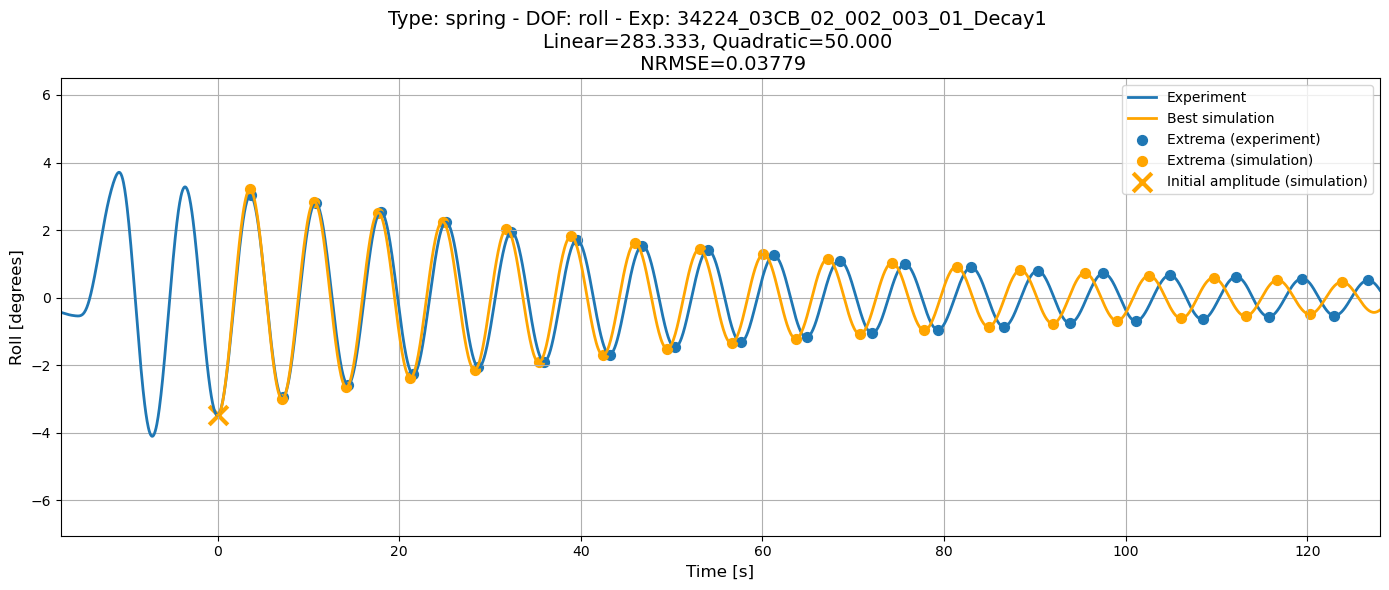

BEST -> lin=283.3333, quad=50.0000, score=0.037788

Experiment: 34224_03CB_02_002_003_01_Decay2.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=2.010048 (peaks=1.965312, troughs=2.054784)
[coarse    2/49] lin=0.0000, quad=166.6667, score=1.889585 (peaks=1.848517, troughs=1.930652)
[coarse    3/49] lin=0.0000, quad=333.3333, score=1.779047 (peaks=1.741027, troughs=1.817068)
[coarse    4/49] lin=0.0000, quad=500.0000, score=1.677342 (peaks=1.642055, troughs=1.712628)
[coarse    5/49] lin=0.0000, quad=666.6667, score=1.583467 (peaks=1.550534, troughs=1.616400)
[coarse    6/49] lin=0.0000, quad=833.3333, score=1.496484 (peaks=1.465882, troughs=1.527087)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.415660 (peaks=1.387201, troughs=1.444119)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.512965 (peaks=0.508378, troughs=0.517552)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.472674 (peaks=0.468698, troughs=0.476649)
[coarse   10/49] lin=166.6667, quad=333.3333, score=0

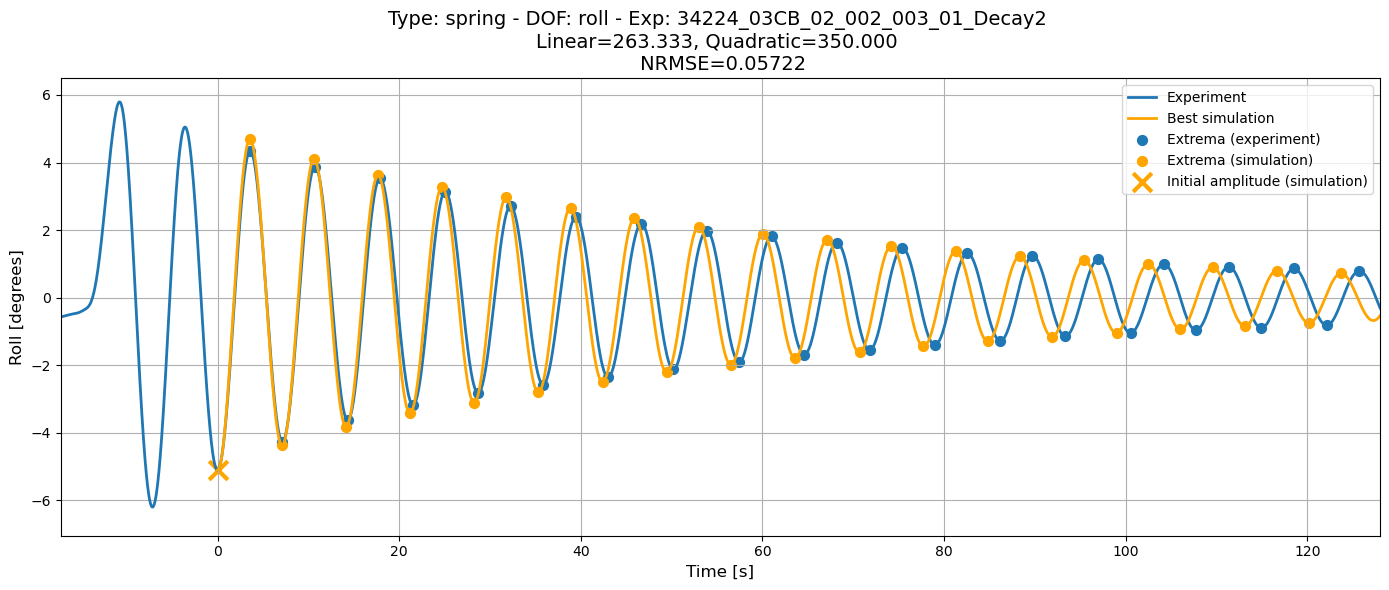

BEST -> lin=263.3333, quad=350.0000, score=0.057220

Experiment: 34224_03CB_02_002_004_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=2.493107 (peaks=2.430994, troughs=2.555220)
[coarse    2/49] lin=0.0000, quad=166.6667, score=2.316701 (peaks=2.260579, troughs=2.372823)
[coarse    3/49] lin=0.0000, quad=333.3333, score=2.157990 (peaks=2.106576, troughs=2.209403)
[coarse    4/49] lin=0.0000, quad=500.0000, score=2.014781 (peaks=1.967796, troughs=2.061765)
[coarse    5/49] lin=0.0000, quad=666.6667, score=1.884401 (peaks=1.841569, troughs=1.927232)
[coarse    6/49] lin=0.0000, quad=833.3333, score=1.765723 (peaks=1.725712, troughs=1.805734)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.657053 (peaks=1.620367, troughs=1.693738)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.766192 (peaks=0.756974, troughs=0.775410)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.704286 (peaks=0.696107, troughs=0.712466)
[coarse   10/49] lin=166.6667, quad=333.3333, score=

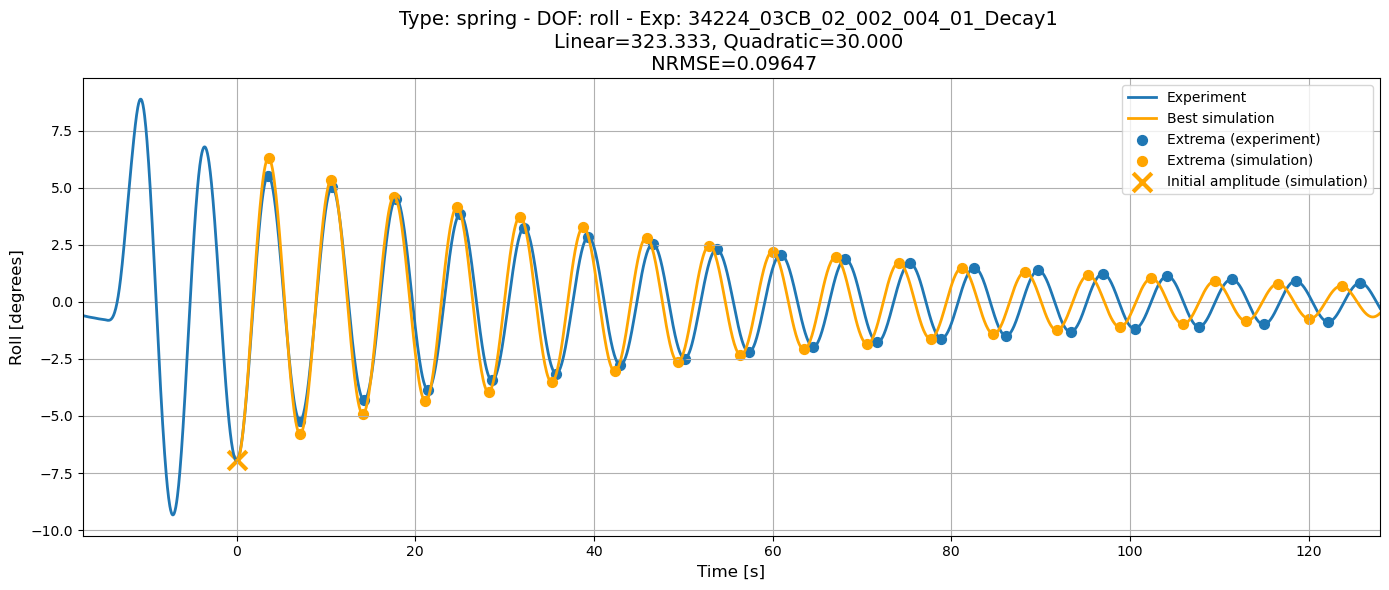

BEST -> lin=323.3333, quad=30.0000, score=0.096465

Experiment: 34224_03CB_02_002_004_01_Decay2.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=2.489169 (peaks=2.487046, troughs=2.491292)
[coarse    2/49] lin=0.0000, quad=166.6667, score=2.321915 (peaks=2.321472, troughs=2.322359)
[coarse    3/49] lin=0.0000, quad=333.3333, score=2.170646 (peaks=2.171620, troughs=2.169672)
[coarse    4/49] lin=0.0000, quad=500.0000, score=2.033435 (peaks=2.035648, troughs=2.031223)
[coarse    5/49] lin=0.0000, quad=666.6667, score=1.908251 (peaks=1.911482, troughs=1.905020)
[coarse    6/49] lin=0.0000, quad=833.3333, score=1.793407 (peaks=1.797519, troughs=1.789295)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.688040 (peaks=1.692796, troughs=1.683285)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.741333 (peaks=0.753786, troughs=0.728880)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.683870 (peaks=0.696377, troughs=0.671362)
[coarse   10/49] lin=166.6667, quad=333.3333, score=0

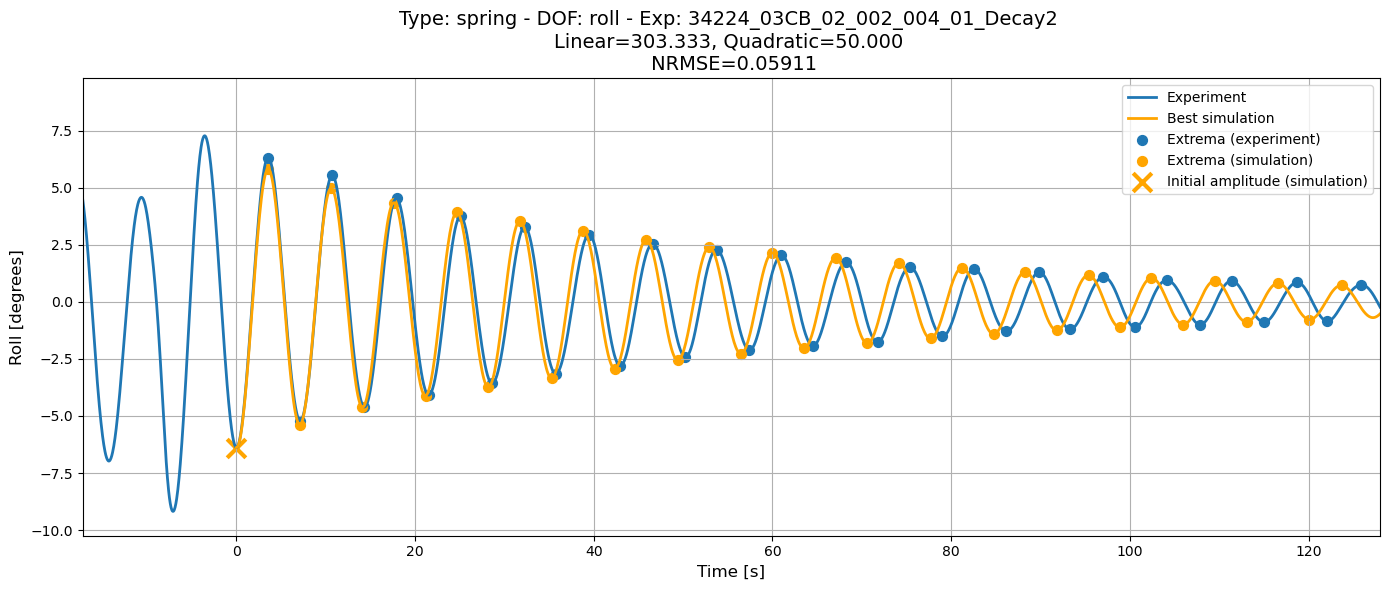

BEST -> lin=303.3333, quad=50.0000, score=0.059112

START: construction=fixedwith, dof=roll, n=3

Experiment: 34224_03CB_02_003_004_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=1.532757 (peaks=1.574055, troughs=1.491460)
[coarse    2/49] lin=0.0000, quad=166.6667, score=1.434886 (peaks=1.473277, troughs=1.396494)
[coarse    3/49] lin=0.0000, quad=333.3333, score=1.344956 (peaks=1.380743, troughs=1.309169)
[coarse    4/49] lin=0.0000, quad=500.0000, score=1.262048 (peaks=1.295507, troughs=1.228588)
[coarse    5/49] lin=0.0000, quad=666.6667, score=1.185379 (peaks=1.216723, troughs=1.154035)
[coarse    6/49] lin=0.0000, quad=833.3333, score=1.114320 (peaks=1.143730, troughs=1.084909)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.048310 (peaks=1.075963, troughs=1.020658)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.266668 (peaks=0.272818, troughs=0.260519)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.236470 (peaks=0.242088, troughs=0.230852)
[coarse

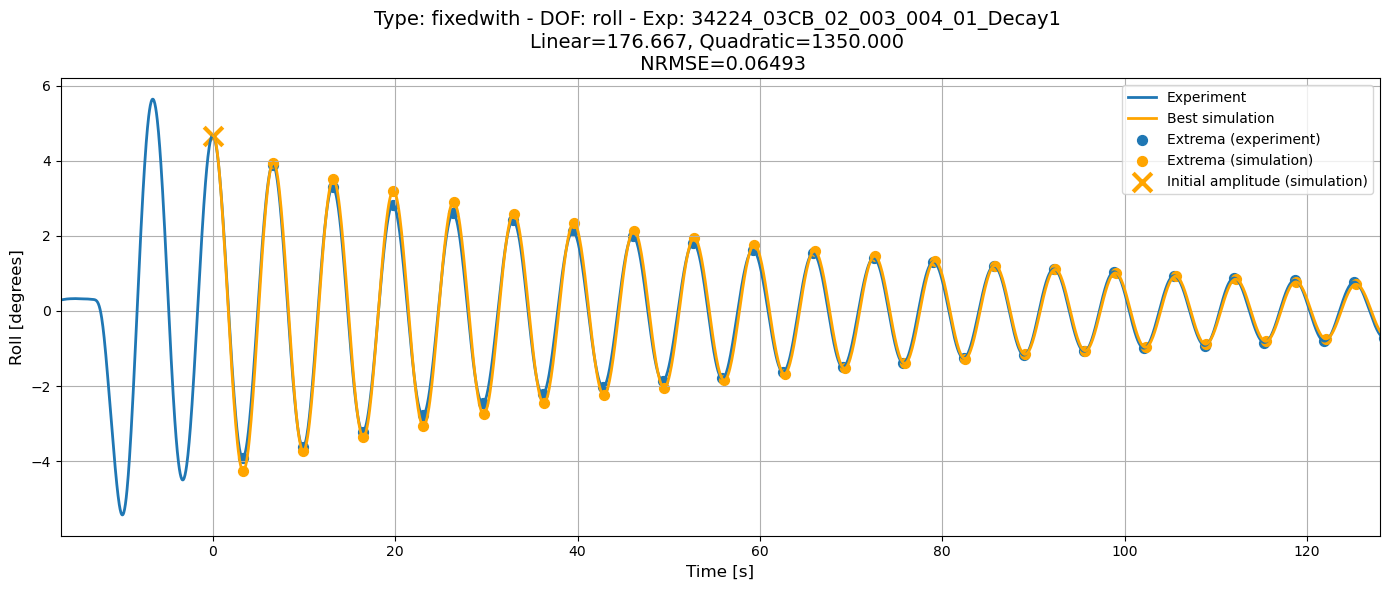

BEST -> lin=176.6667, quad=1350.0000, score=0.064927

Experiment: 34224_03CB_02_003_005_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=2.874909 (peaks=2.816497, troughs=2.933321)
[coarse    2/49] lin=0.0000, quad=166.6667, score=2.688132 (peaks=2.634568, troughs=2.741697)
[coarse    3/49] lin=0.0000, quad=333.3333, score=2.519103 (peaks=2.469811, troughs=2.568395)
[coarse    4/49] lin=0.0000, quad=500.0000, score=2.365671 (peaks=2.320140, troughs=2.411202)
[coarse    5/49] lin=0.0000, quad=666.6667, score=2.226035 (peaks=2.183923, troughs=2.268147)
[coarse    6/49] lin=0.0000, quad=833.3333, score=2.098762 (peaks=2.059693, troughs=2.137831)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.982280 (peaks=1.945821, troughs=2.018740)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.841376 (peaks=0.833366, troughs=0.849385)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.783085 (peaks=0.775945, troughs=0.790225)
[coarse   10/49] lin=166.6667, quad=333.3333, score

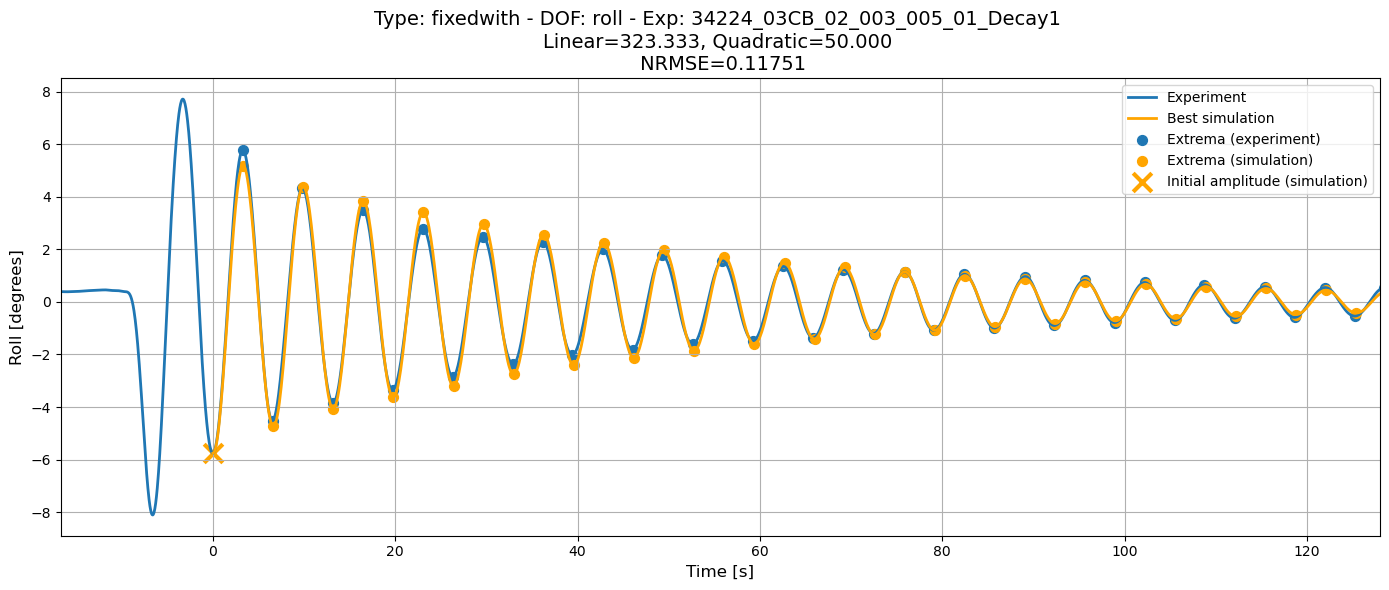

BEST -> lin=323.3333, quad=50.0000, score=0.117513

Experiment: 34224_03CB_02_003_006_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=2.043591 (peaks=2.017031, troughs=2.070151)
[coarse    2/49] lin=0.0000, quad=166.6667, score=1.877428 (peaks=1.854355, troughs=1.900500)
[coarse    3/49] lin=0.0000, quad=333.3333, score=1.729567 (peaks=1.709499, troughs=1.749634)
[coarse    4/49] lin=0.0000, quad=500.0000, score=1.597950 (peaks=1.580359, troughs=1.615542)
[coarse    5/49] lin=0.0000, quad=666.6667, score=1.479149 (peaks=1.463646, troughs=1.494653)
[coarse    6/49] lin=0.0000, quad=833.3333, score=1.371426 (peaks=1.357751, troughs=1.385101)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=1.273575 (peaks=1.261574, troughs=1.285576)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.567601 (peaks=0.570016, troughs=0.565186)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.512599 (peaks=0.515438, troughs=0.509760)
[coarse   10/49] lin=166.6667, quad=333.3333, score=0

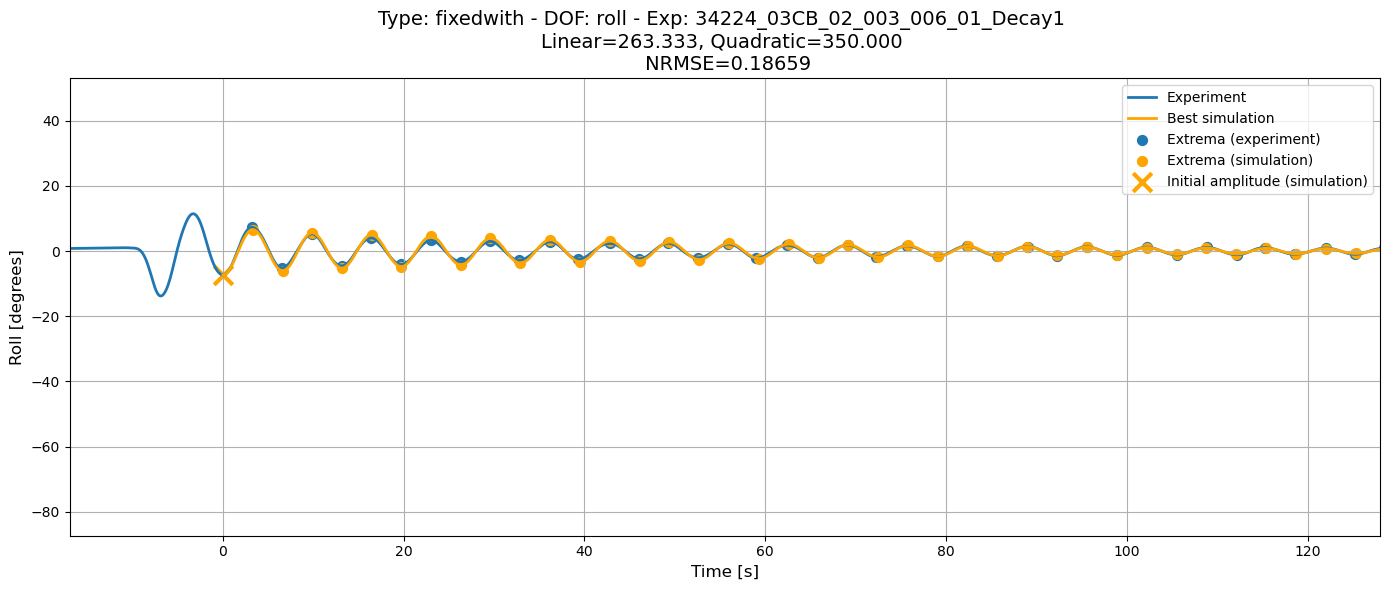

BEST -> lin=263.3333, quad=350.0000, score=0.186588

START: construction=fixedwithout, dof=roll, n=4

Experiment: 34224_03CB_02_004_005_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=0.529379 (peaks=0.516982, troughs=0.541776)
[coarse    2/49] lin=0.0000, quad=166.6667, score=0.486824 (peaks=0.475627, troughs=0.498021)
[coarse    3/49] lin=0.0000, quad=333.3333, score=0.447065 (peaks=0.436976, troughs=0.457155)
[coarse    4/49] lin=0.0000, quad=500.0000, score=0.409846 (peaks=0.400786, troughs=0.418906)
[coarse    5/49] lin=0.0000, quad=666.6667, score=0.374948 (peaks=0.366856, troughs=0.383040)
[coarse    6/49] lin=0.0000, quad=833.3333, score=0.342182 (peaks=0.335005, troughs=0.349359)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=0.311388 (peaks=0.305081, troughs=0.317695)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.220516 (peaks=0.219551, troughs=0.221480)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.233353 (peaks=0.232053, troughs=0.234652)
[co

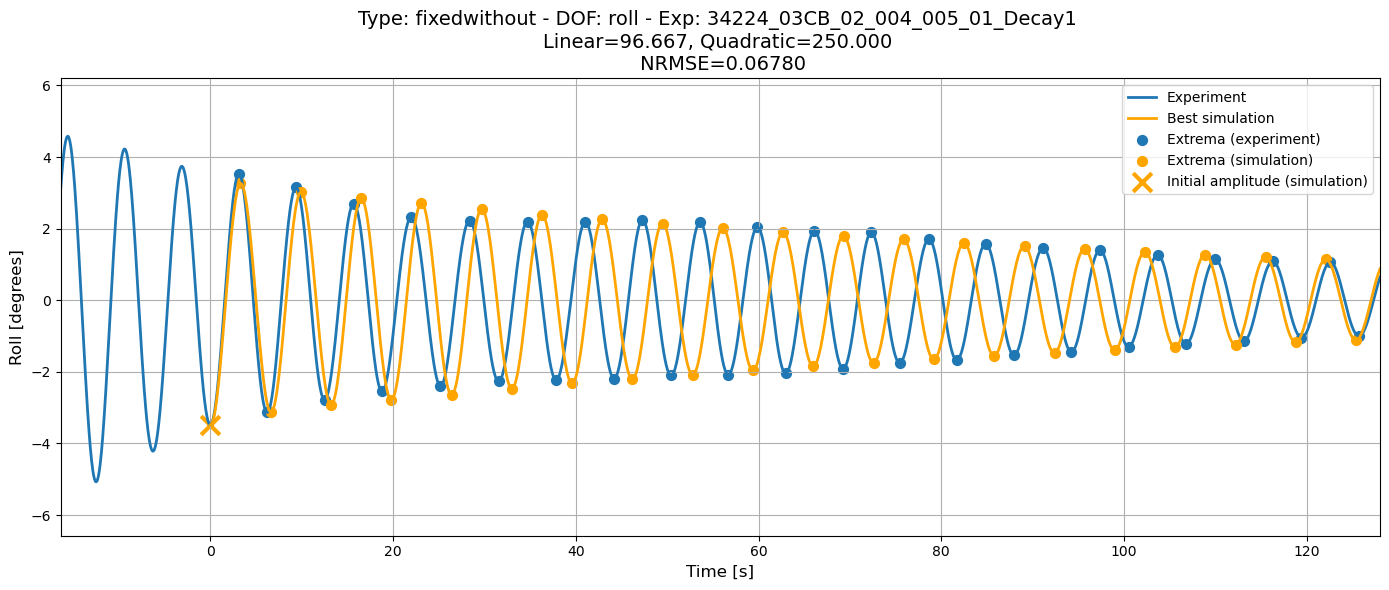

BEST -> lin=96.6667, quad=250.0000, score=0.067801

Experiment: 34224_03CB_02_004_006_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=1.115300 (peaks=1.086506, troughs=1.144094)
[coarse    2/49] lin=0.0000, quad=166.6667, score=1.033812 (peaks=1.007240, troughs=1.060384)
[coarse    3/49] lin=0.0000, quad=333.3333, score=0.959081 (peaks=0.934456, troughs=0.983706)
[coarse    4/49] lin=0.0000, quad=500.0000, score=0.890261 (peaks=0.867394, troughs=0.913128)
[coarse    5/49] lin=0.0000, quad=666.6667, score=0.826675 (peaks=0.805385, troughs=0.847965)
[coarse    6/49] lin=0.0000, quad=833.3333, score=0.767734 (peaks=0.747870, troughs=0.787598)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=0.712962 (peaks=0.694408, troughs=0.731516)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.147776 (peaks=0.143041, troughs=0.152510)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.131730 (peaks=0.127401, troughs=0.136060)
[coarse   10/49] lin=166.6667, quad=333.3333, score=0

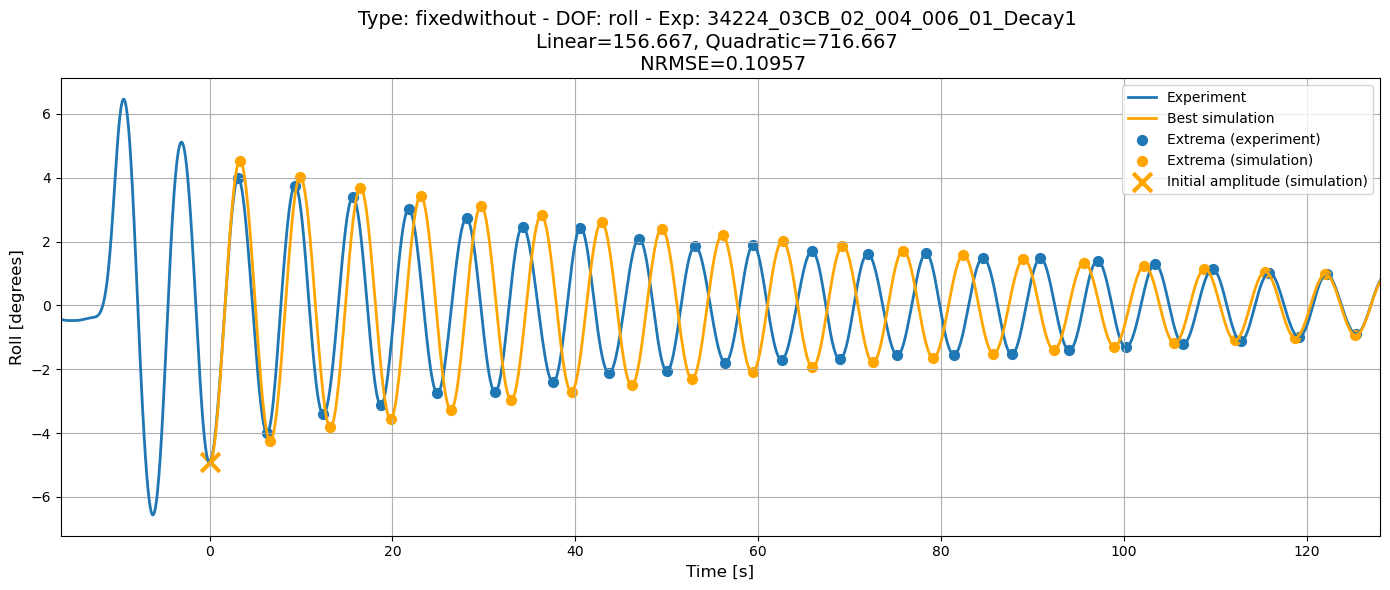

BEST -> lin=156.6667, quad=716.6667, score=0.109569

Experiment: 34224_03CB_02_004_007_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=0.984849 (peaks=0.964899, troughs=1.004798)
[coarse    2/49] lin=0.0000, quad=166.6667, score=0.922466 (peaks=0.904005, troughs=0.940927)
[coarse    3/49] lin=0.0000, quad=333.3333, score=0.864365 (peaks=0.847249, troughs=0.881481)
[coarse    4/49] lin=0.0000, quad=500.0000, score=0.810112 (peaks=0.794224, troughs=0.826000)
[coarse    5/49] lin=0.0000, quad=666.6667, score=0.759330 (peaks=0.744557, troughs=0.774103)
[coarse    6/49] lin=0.0000, quad=833.3333, score=0.711686 (peaks=0.697935, troughs=0.725438)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=0.666893 (peaks=0.654083, troughs=0.679704)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.046526 (peaks=0.043263, troughs=0.049789)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.050885 (peaks=0.047307, troughs=0.054464)
[coarse   10/49] lin=166.6667, quad=333.3333, score=

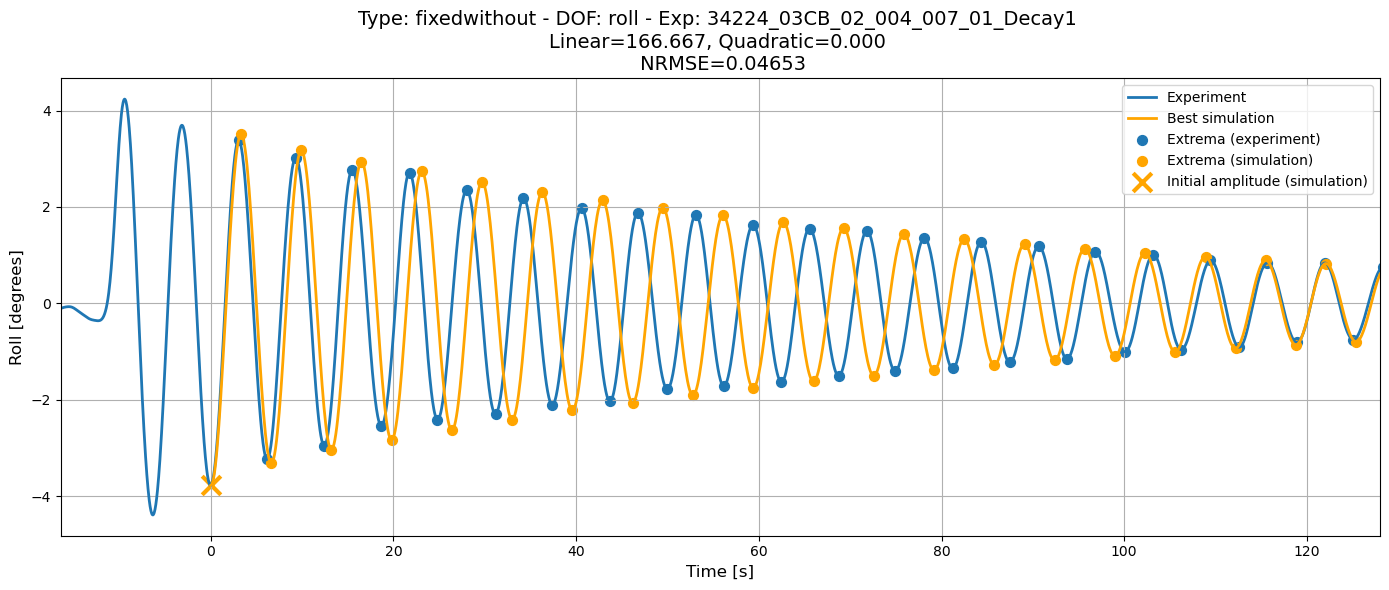

BEST -> lin=166.6667, quad=0.0000, score=0.046526

Experiment: 34224_03CB_02_004_008_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=0.615481 (peaks=0.599008, troughs=0.631954)
[coarse    2/49] lin=0.0000, quad=166.6667, score=0.571297 (peaks=0.556021, troughs=0.586572)
[coarse    3/49] lin=0.0000, quad=333.3333, score=0.529854 (peaks=0.515683, troughs=0.544025)
[coarse    4/49] lin=0.0000, quad=500.0000, score=0.490899 (peaks=0.477747, troughs=0.504051)
[coarse    5/49] lin=0.0000, quad=666.6667, score=0.454215 (peaks=0.441998, troughs=0.466431)
[coarse    6/49] lin=0.0000, quad=833.3333, score=0.419610 (peaks=0.408269, troughs=0.430951)
[coarse    7/49] lin=0.0000, quad=1000.0000, score=0.386921 (peaks=0.376392, troughs=0.397450)
[coarse    8/49] lin=166.6667, quad=0.0000, score=0.174485 (peaks=0.173372, troughs=0.175598)
[coarse    9/49] lin=166.6667, quad=166.6667, score=0.187968 (peaks=0.186583, troughs=0.189353)
[coarse   10/49] lin=166.6667, quad=333.3333, score=0.

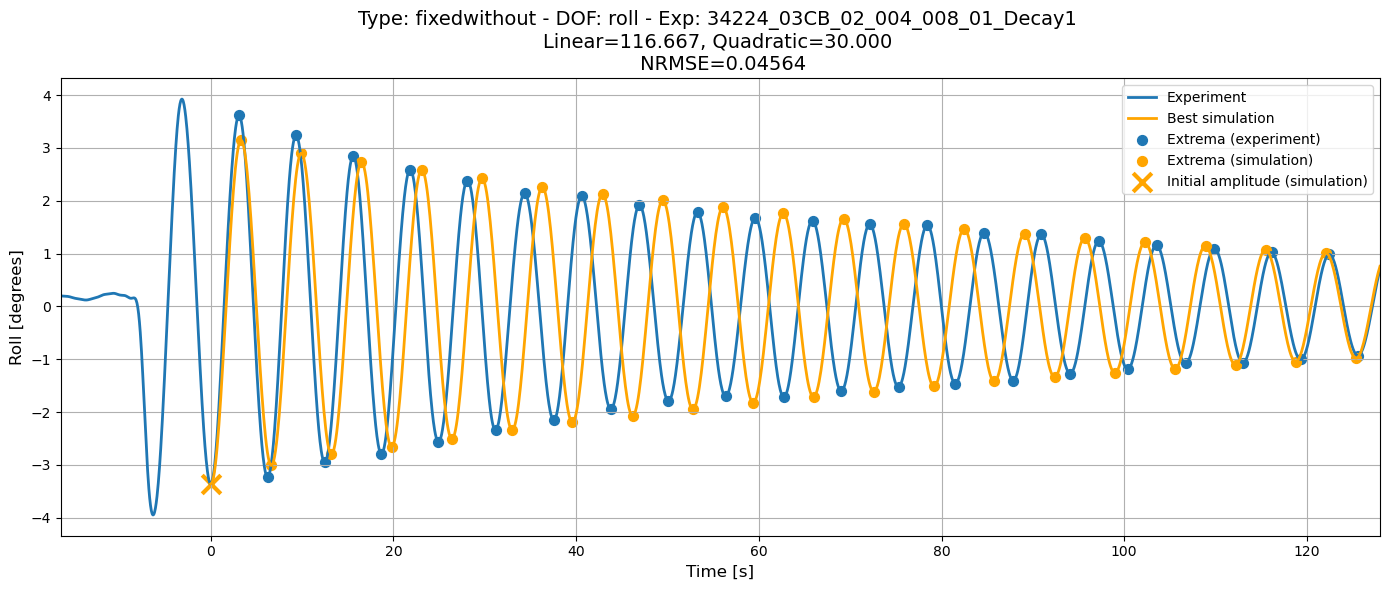

BEST -> lin=116.6667, quad=30.0000, score=0.045638

Klaar.
Aantal geslaagde calibraties: 11
Aantal fouten: 0


In [45]:
# ============================================================
# NOTEBOOK 10 - Alles runnen
# ============================================================
all_results = []
failed_cases = []

for construction, dof_dict in exp_paths.items():
    for dof, path_list in dof_dict.items():
        print("\n" + "=" * 80)
        print(f"START: construction={construction}, dof={dof}, n={len(path_list)}")
        print("=" * 80)

        for exp_path in path_list:
            print(f"\nExperiment: {exp_path.name}")

            try:
                exp_info = prepare_experiment(exp_path, dof)
                result = calibrate_single_experiment(exp_info, construction, dof, verbose=True)
                all_results.append(result)
                plot_best_fit(result, plots_dir)

                print(
                    f"BEST -> lin={result['best_lin']:.4f}, "
                    f"quad={result['best_quad']:.4f}, "
                    f"score={result['best_score']:.6f}"
                )

            except Exception as e:
                warnings.warn(f"Fout bij {exp_path}: {e}")
                failed_cases.append({
                    "construction": construction,
                    "dof": dof,
                    "exp_path": str(exp_path),
                    "error": str(e),
                })

print("\nKlaar.")
print(f"Aantal geslaagde calibraties: {len(all_results)}")
print(f"Aantal fouten: {len(failed_cases)}")


In [46]:
# ============================================================
# NOTEBOOK 11 - Resultaten naar DataFrame
# ============================================================
results_rows = []
for r in all_results:
    results_rows.append({
        "construction": r["construction"],
        "dof": r["dof"],
        "exp_path": r["exp_path"],
        "file_name": Path(r["exp_path"]).name,
        "intial amplitude": r["a_A1"],       
      
        "extremum_type": r["extremum_type"],
        "sim_init_time": r["sim_init_time"],
        "sim_init_amplitude": r["sim_init_amp"],
        "linear_damping": r["best_lin"],
        "quadratic_damping": r["best_quad"],
        "nmrse_total": r["best_score"],
        "nrmse_peaks": r["best_nrmse_peaks"],
        "nrmse_troughs": r["best_nrmse_troughs"],
    })

df_results = pd.DataFrame(results_rows)
df_failed = pd.DataFrame(failed_cases)

display(df_results.head())
if len(df_failed) > 0:
    display(df_failed.head())


,construction,dof,exp_path,file_name,intial amplitude,extremum_type,sim_init_time,sim_init_amplitude,linear_damping,quadratic_damping,nmrse_total,nrmse_peaks,nrmse_troughs
0,spring,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_003_01_Decay1.h5m,-4.108790,trough,0.0,-3.483344,283.333333,50.0,0.037788,0.043991,0.031585
1,spring,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_003_01_Decay2.h5m,-6.205867,trough,0.0,-5.108450,263.333333,350.0,0.057220,0.059491,0.054948
2,spring,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_004_01_Decay1.h5m,-9.337518,trough,0.0,-6.944191,323.333333,30.0,0.096465,0.094293,0.098638
3,spring,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_004_01_Decay2.h5m,-9.182566,trough,0.0,-6.382850,303.333333,50.0,0.059112,0.068208,0.050016
4,fixedwith,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_003_004_01_Decay1.h5m,5.642398,peak,0.0,4.671509,176.666667,1350.0,0.064927,0.066316,0.063538


In [47]:
# ============================================================
# NOTEBOOK 12 - Excel export per DOF
# ============================================================
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for dof in ["pitch", "roll", "heave"]:
        df_dof = df_results[df_results["dof"] == dof].copy()
        df_dof = df_dof.sort_values(["construction", "file_name"])
        df_dof.to_excel(writer, sheet_name=dof, index=False)

    if len(df_failed) > 0:
        df_failed.to_excel(writer, sheet_name="failed_cases", index=False)

print(f"Excel opgeslagen naar:\n{excel_path}")
print(f"Plots opgeslagen in:\n{plots_dir}")


Excel opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\calibrated_roll_decay_coefficients.xlsx
Plots opgeslagen in:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\plots
